In [5]:
#!pip install seaborn
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [6]:
df= pd.read_csv("smartcart_customers.csv")

In [7]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [8]:
df.info
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

# data preprocessing

# handing missing values


In [9]:
#df.fillna(df.median(numeric_only=True), inplace=True)
df["Income"] = df["Income"].fillna(df["Income"].median())

In [10]:
df.isnull().sum()
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


# Feature Engineering

In [11]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response'],
      dtype='str')

In [12]:
# Age
#from datetime import datetime
#current_year = datetime.now().year

df["Age"]= 2026-df["Year_Birth"]
#df.drop("Year_Birth", axis=1, inplace=True)

In [13]:
#Customer Joining Date

df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True)

reference_date = df["Dt_Customer"].max()
df["Customer_Tenure_days"] = (reference_date - df["Dt_Customer"]).dt.days

In [14]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_days
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,88,3,8,10,4,7,0,1,69,663
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,6,2,1,1,2,5,0,0,72,113
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,42,1,8,2,10,4,0,0,61,312
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,5,2,2,0,4,6,0,0,42,139
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,15,5,5,3,6,5,0,0,45,161


In [15]:
#spending
df["total_spending"]= df['MntWines']+ df['MntFruits']+ df['MntMeatProducts']+ df['MntFishProducts']+ df['MntSweetProducts']+ df['MntGoldProds']


In [16]:
# children

df["Total_children"] = df["Kidhome"] + df["Teenhome"]

In [17]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_days,total_spending,Total_children
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,8,10,4,7,0,1,69,663,1617,0
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,1,1,2,5,0,0,72,113,27,2
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,8,2,10,4,0,0,61,312,776,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,2,0,4,6,0,0,42,139,53,1
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,3,6,5,0,0,45,161,422,1


In [18]:
# Education

df["Education"].value_counts()

df["Education"] = df["Education"].replace({
    "Basic": "Undergraduate", "2n Cycle": "Undergraduate",
    "Graduation": "Graduate",
    "PhD": "Postgradate" , "Master": "Postgradate"
})

#undergraduate, graduate, postgradate

In [19]:
df["Education"].value_counts()

Education
Graduate         1127
Postgradate       856
Undergraduate     257
Name: count, dtype: int64

In [20]:
df["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [21]:
df["Living_with"] = df["Marital_Status"].replace({
    "Married": "Partner", "Together": "Partner",
    "Single": "Alone", "YOLO": "Alone",
    "Divorced": "Alone" , "Widow": "Alone",
    "Alone": "Alone" , "Absurd": "Alone"
    
})


In [22]:
df["Living_with"].value_counts()

Living_with
Partner    1444
Alone       796
Name: count, dtype: int64

In [23]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_days,total_spending,Total_children,Living_with
0,5524,1957,Graduate,Single,58138.0,0,0,2012-09-04,58,635,...,10,4,7,0,1,69,663,1617,0,Alone
1,2174,1954,Graduate,Single,46344.0,1,1,2014-03-08,38,11,...,1,2,5,0,0,72,113,27,2,Alone
2,4141,1965,Graduate,Together,71613.0,0,0,2013-08-21,26,426,...,2,10,4,0,0,61,312,776,0,Partner
3,6182,1984,Graduate,Together,26646.0,1,0,2014-02-10,26,11,...,0,4,6,0,0,42,139,53,1,Partner
4,5324,1981,Postgradate,Married,58293.0,1,0,2014-01-19,94,173,...,3,6,5,0,0,45,161,422,1,Partner


## Drop Columns

In [24]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_days,total_spending,Total_children,Living_with
0,5524,1957,Graduate,Single,58138.0,0,0,2012-09-04,58,635,...,10,4,7,0,1,69,663,1617,0,Alone
1,2174,1954,Graduate,Single,46344.0,1,1,2014-03-08,38,11,...,1,2,5,0,0,72,113,27,2,Alone
2,4141,1965,Graduate,Together,71613.0,0,0,2013-08-21,26,426,...,2,10,4,0,0,61,312,776,0,Partner
3,6182,1984,Graduate,Together,26646.0,1,0,2014-02-10,26,11,...,0,4,6,0,0,42,139,53,1,Partner
4,5324,1981,Postgradate,Married,58293.0,1,0,2014-01-19,94,173,...,3,6,5,0,0,45,161,422,1,Partner


In [25]:
cols = ["ID","Year_Birth","Marital_Status","Kidhome","Teenhome","Dt_Customer"]
spending_cols = ['MntWines', 'MntFruits', 'MntMeatProducts','MntFishProducts', 'MntSweetProducts', 'MntGoldProds']

cols_to_drop = cols+ spending_cols
df_cleaned = df.drop(columns=cols_to_drop)

In [26]:
df_cleaned.shape

(2240, 15)

In [27]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_days,total_spending,Total_children,Living_with
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,Postgradate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


# Outliers

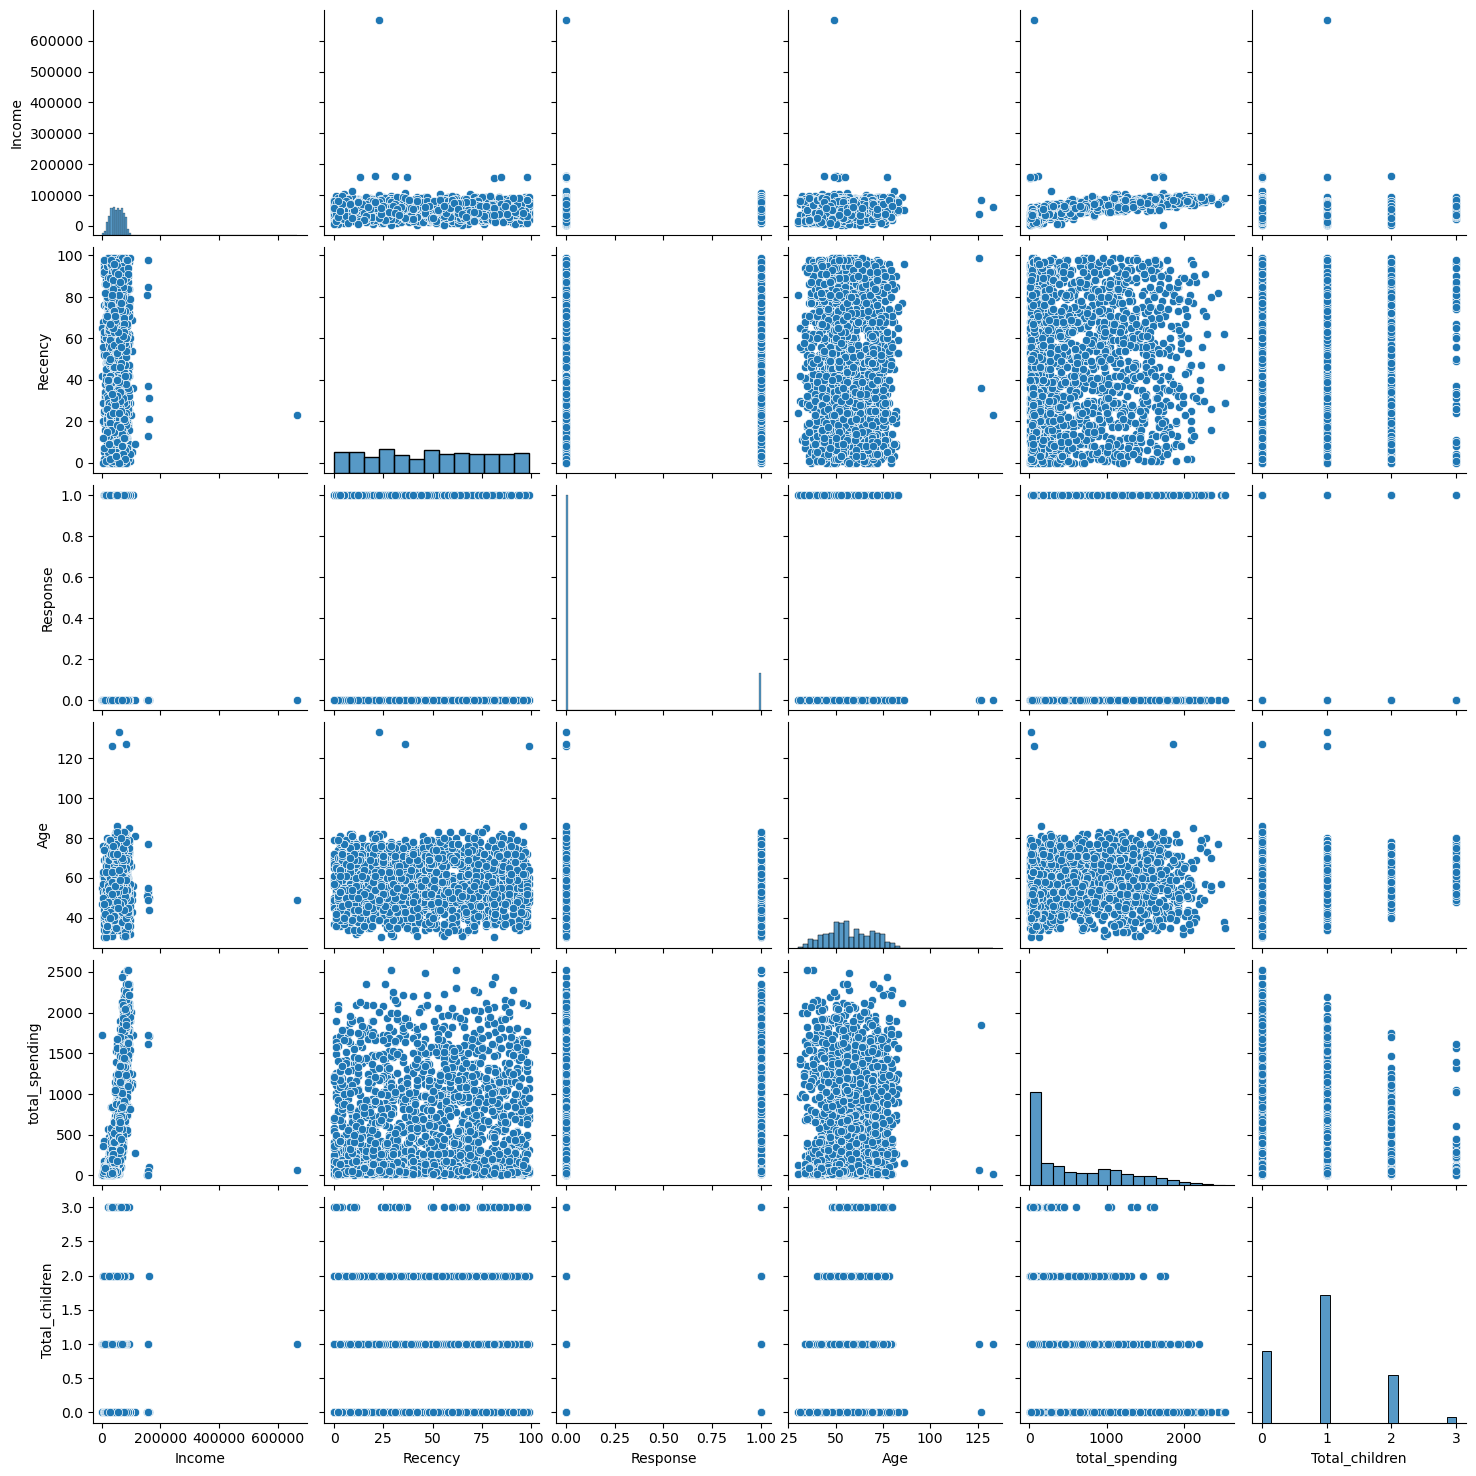

In [28]:
cols = ["Income","Recency","Response","Age", "total_spending", "Total_children" ]

# relative plot of some features - pair ploy
sns.pairplot(df_cleaned[cols])

In [29]:
# Remove outlier
print("data size with outlier: ", len(df_cleaned))

df_cleaned =df_cleaned[ (df_cleaned["Age"]<90) ]
df_cleaned =df_cleaned[ (df_cleaned["Income"]<600_000) ]
print("data size with outlier: ", len(df_cleaned))

data size with outlier:  2240
data size with outlier:  2236


# HeatMap

In [30]:
corr= df_cleaned.corr(numeric_only = True)

<Axes: >

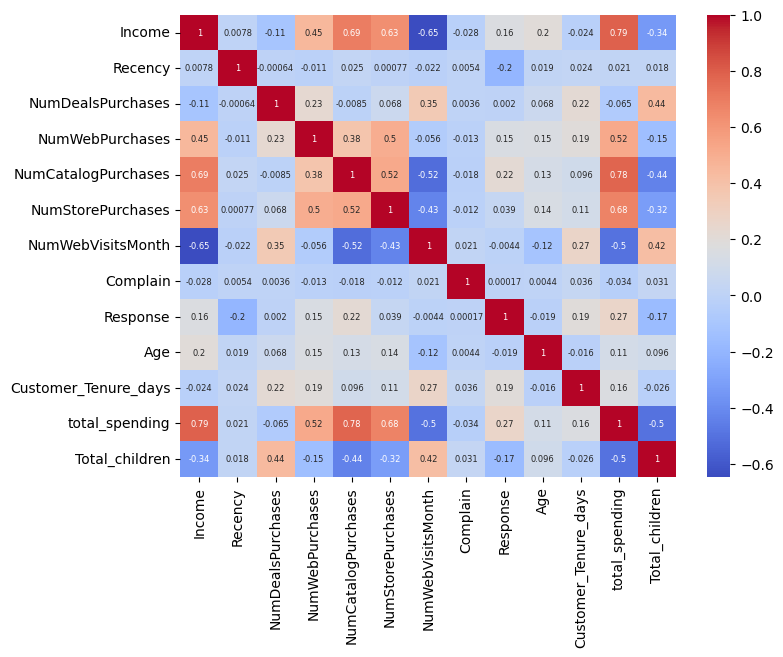

In [31]:
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    annot_kws = {"size":6},
    cmap="coolwarm"
)

In [32]:
df_cleaned.shape

(2236, 15)

In [33]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_days,total_spending,Total_children,Living_with
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,Postgradate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


# Feature Encoding

In [34]:
from sklearn.preprocessing import OneHotEncoder

In [35]:
ohe= OneHotEncoder()

cat_cols=["Education","Living_with"]

enc_cols= ohe.fit_transform(df_cleaned[cat_cols])

In [36]:
enc_df = pd.DataFrame(enc_cols.toarray(), columns=ohe.get_feature_names_out(cat_cols),index=df_cleaned.index)



In [37]:
df_encoded = pd.concat([df_cleaned.drop(columns = cat_cols), enc_df],axis=1)

In [38]:
df_encoded.shape

(2236, 18)

In [39]:

df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_days,total_spending,Total_children,Education_Graduate,Education_Postgradate,Education_Undergraduate,Living_with_Alone,Living_with_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0


# scaling

In [40]:
from sklearn.preprocessing import StandardScaler

In [41]:
X= df_encoded

In [42]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# visualize

In [39]:
X_scaled.shape

(2236, 18)

In [40]:
# 2D
from sklearn.decomposition import PCA


In [52]:
pca= PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

In [53]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

Text(0.5, 0.92, '3d projection')

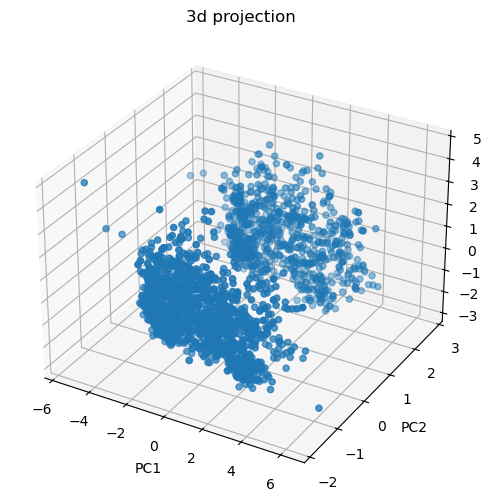

In [54]:
#plot
fig = plt.figure(figsize=(8,6))

ax= fig.add_subplot(111, projection="3d")

ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2])


ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("3d projection")

In [47]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

# Analyze k value
# 1.Elbow Method

In [58]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

In [59]:
wcss= []
for k in range(1,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

In [61]:
knee = KneeLocator(range(1,11), wcss, curve="convex" , direction="decreasing")
optimal_k = knee.elbow

In [64]:
print("best k = ",optimal_k)

best k =  4


Text(0.5, 1.0, 'plt')

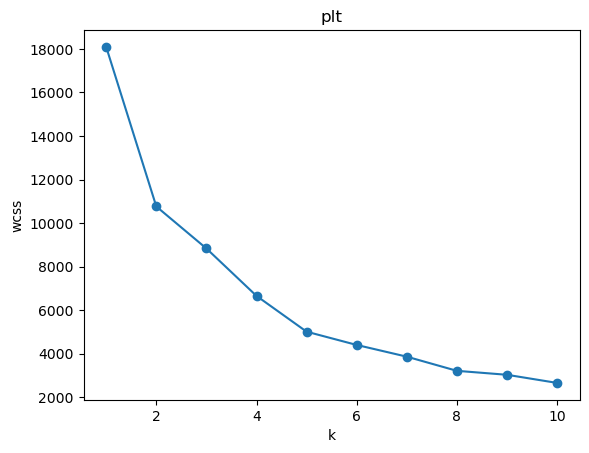

In [66]:
#plot

plt.plot(range(1,11), wcss, marker="o")
plt.xlabel("k")
plt.ylabel("wcss")
plt.title("plt")

# 2.Silhoutte Score

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

Text(0, 0.5, 'silhouette_score')

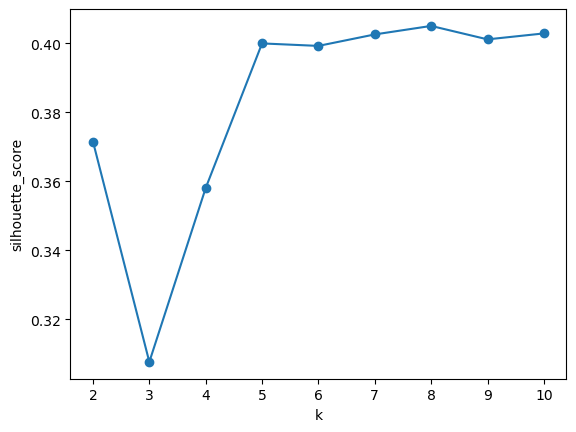

In [73]:
from sklearn.metrics import silhouette_score

scores= []

for k in range(2,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels=kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    scores.append(score)

#plot
plt.plot(range(2,11), scores , marker="o")
plt.xlabel("k")
plt.ylabel("silhouette_score")

Text(0, 0.5, 'score')

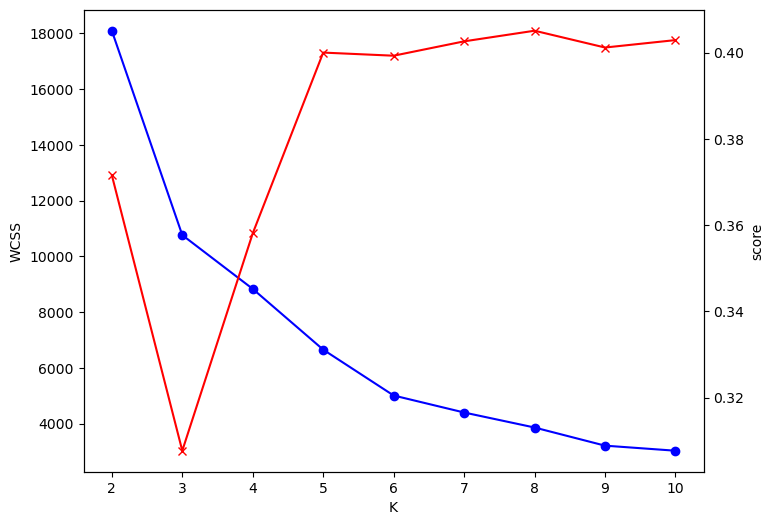

In [79]:
# combined plot

k_range=range(2,11)
fig, ax1 =plt.subplots(figsize=(8,6))

ax1.plot(k_range , wcss[:len(k_range)], marker="o", color="blue")
ax1.set_xlabel("K")
ax1.set_ylabel("WCSS")

ax2=ax1.twinx()
ax2.plot(k_range , scores[:len(k_range)], marker="x", color="red")
ax2.set_ylabel("score")

# clustering

In [82]:
# K_means

kmeans = KMeans(n_clusters = 4, random_state=42)
labels_kmeans = kmeans.fit_predict(X_pca)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(


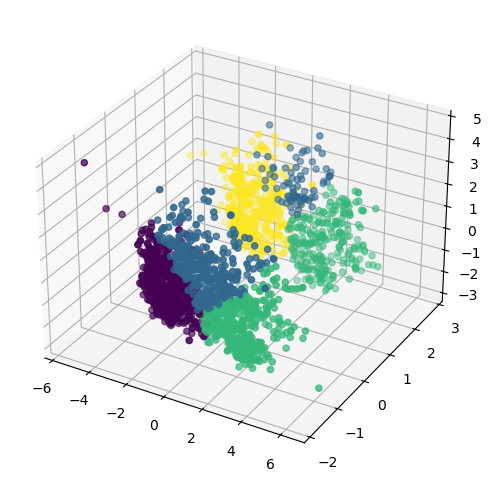

In [84]:
#plot
fig = plt.figure(figsize=(8,6))

ax= fig.add_subplot(111, projection="3d")

ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2], c=labels_kmeans)

In [85]:
# Agglormerative Clustering
from sklearn.cluster import AgglomerativeClustering

In [89]:
agg_clf = AgglomerativeClustering(n_clusters= 4, linkage="ward")
labels_agg= agg_clf.fit_predict(X_pca)

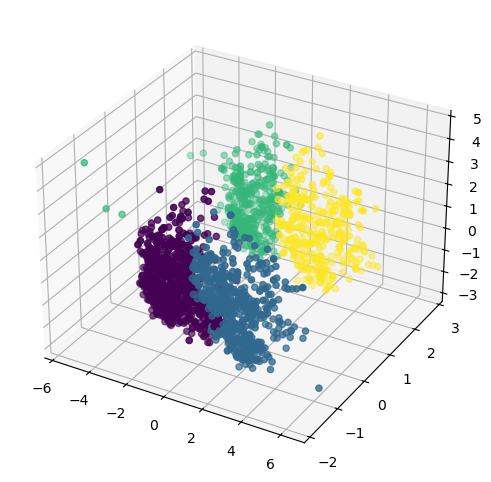

In [90]:
#plot
fig = plt.figure(figsize=(8,6))

ax= fig.add_subplot(111, projection="3d")

ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2], c=labels_agg)

# Characterization of Clusters

In [99]:
X["cluster"] = labels_agg

In [100]:
X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_days,total_spending,Total_children,Education_Graduate,Education_Postgradate,Education_Undergraduate,Living_with_Alone,Living_with_Partner,cluster
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,0


<Axes: xlabel='cluster', ylabel='count'>

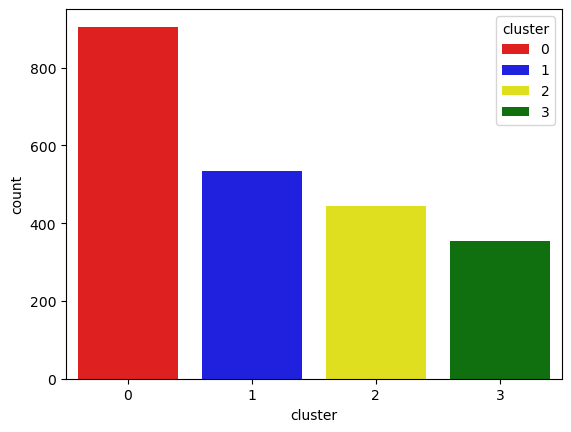

In [101]:
pal = ["red","blue", "yellow", "green"]

sns.countplot(x=X["cluster"], palette = pal, hue=df_cleaned["cluster"])

<Axes: xlabel='total_spending', ylabel='Income'>

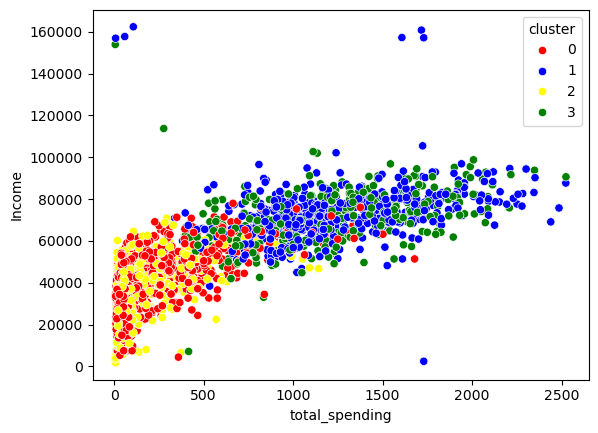

In [102]:
# Income & Spending patterns

sns.scatterplot(x=X["total_spending"], y=X["Income"], hue=X["cluster"],palette=pal)


In [103]:
# cluster summary

cluster_summary = X.groupby("cluster").mean()
print(cluster_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        39680.580110  48.914917           2.594475         3.153591   
1        72808.445693  49.202247           1.958801         5.687266   
2        36960.143018  48.319820           2.594595         2.713964   
3        70722.681303  50.504249           1.855524         5.790368   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   0.969061           4.143646           6.307182  0.011050   
1                   5.498127           8.659176           3.580524  0.005618   
2                   0.837838           3.623874           6.659910  0.011261   
3                   5.014164           8.430595           3.728045  0.005666   

         Response        Age  Customer_Tenure_days  total_spending  \
cluster         

In [50]:
with open(".gitignore", "w") as f:
    f.write("smartcart_customers.csv\n.ipynb_checkpoints/")